# Mushroom Insights — Görselleştirmeler

Bu defter `mushroom-classification.ipynb`'i **değiştirmez**; onun dışa aktardığı
`insights.json` istatistiklerini ve `mushrooms.csv` verisini okuyup web sitesinin
"Mantar Bilgi Bankası" bölümünde kullanılan grafikleri üretir.

Çıktılar → `static/assets/*.png`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

ASSETS = Path("static/assets")
ASSETS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("mushrooms.csv")
insights = json.loads(Path("insights.json").read_text())

print(f"{len(df)} mantar, {df.shape[1] - 1} özellik")

8124 mantar, 22 özellik


In [2]:
# ── Site ile aynı gece-ormanı paleti ──────────────────────────────────────────
BG      = "#0f1512"
GRID    = "#25322b"
TEXT    = "#e9efe9"
MUTED   = "#8fa396"
GREEN   = "#5fd67f"   # yenilebilir
RED     = "#ff6b5e"   # zehirli
AMBER   = "#e8b25f"   # vurgu

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": TEXT,
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "figure.dpi": 150,
})

def finish(fig, name):
    fig.tight_layout()
    fig.savefig(ASSETS / name, bbox_inches="tight", pad_inches=0.35)
    print("kaydedildi →", ASSETS / name)
    plt.show()

## 1. Veri seti dengesi

kaydedildi → static/assets/class-balance.png


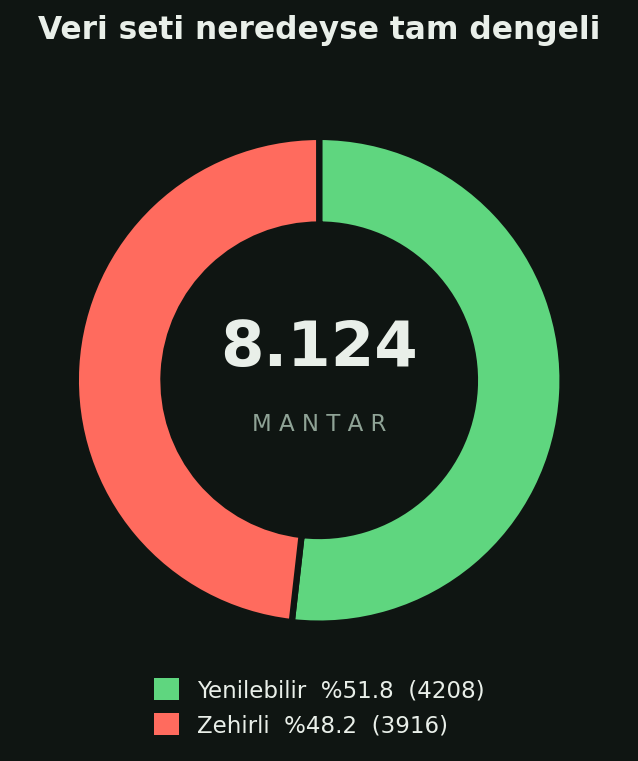

In [3]:
d = insights["dataset"]

fig, ax = plt.subplots(figsize=(6.4, 5.2))
wedges, _ = ax.pie(
    [d["edible"], d["poisonous"]],
    colors=[GREEN, RED],
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.36, edgecolor=BG, linewidth=3),
)
ax.text(0, 0.13, f'{d["total"]:,}'.replace(",", "."), ha="center", va="center",
        fontsize=30, fontweight="bold", color=TEXT)
ax.text(0, -0.18, "M A N T A R", ha="center", va="center", fontsize=11,
        color=MUTED)
ax.set_title("Veri seti neredeyse tam dengeli", pad=18)
ax.legend(
    handles=[
        Patch(facecolor=GREEN, label=f'Yenilebilir  %{d["edible_pct"]}  ({d["edible"]})'),
        Patch(facecolor=RED, label=f'Zehirli  %{d["poisonous_pct"]}  ({d["poisonous"]})'),
    ],
    loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=1,
    frameon=False, labelcolor=TEXT, handlelength=1.1, handleheight=1.1,
)
finish(fig, "class-balance.png")

## 2. Hangi özellik zehri ele veriyor? (Cramér's V)

kaydedildi → static/assets/feature-importance.png


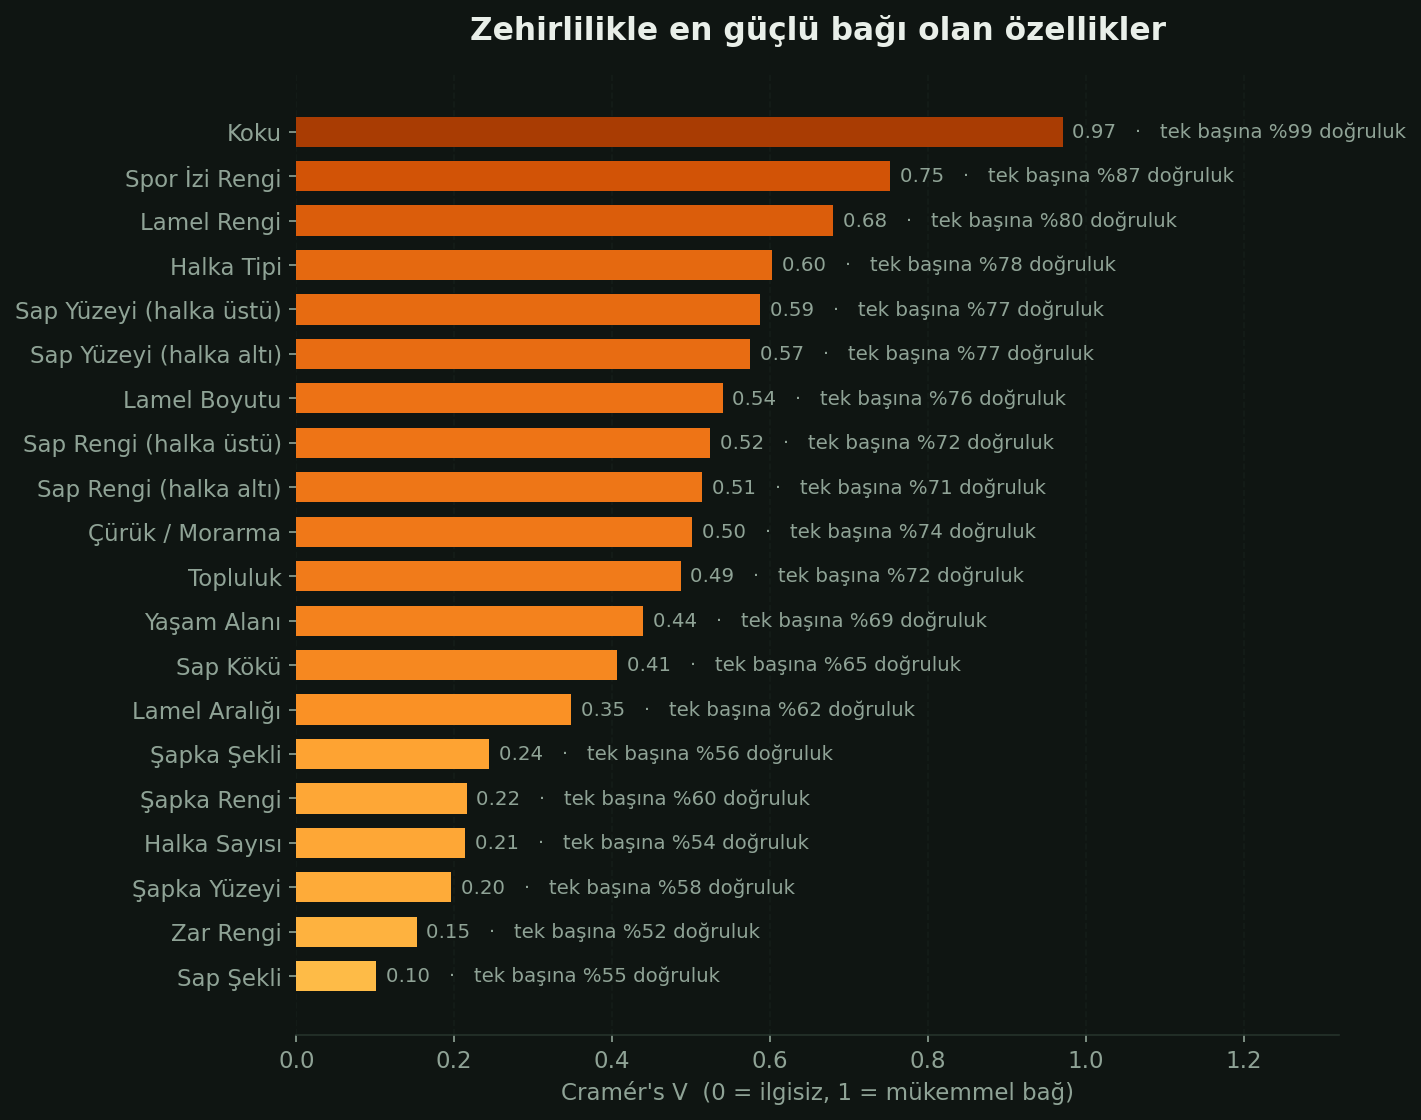

In [4]:
imp = insights["feature_importance"]
labels = [f["label"] for f in imp][::-1]
values = [f["cramers_v"] for f in imp][::-1]
accs   = [f["rule_accuracy"] for f in imp][::-1]

fig, ax = plt.subplots(figsize=(9.5, 7.6))
cmap = plt.cm.YlOrBr
bars = ax.barh(labels, values, height=0.68,
               color=[cmap(0.35 + 0.5 * v) for v in values])

for bar, v, a in zip(bars, values, accs):
    ax.text(v + 0.012, bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}   ·   tek başına %{a:.0f} doğruluk",
            va="center", fontsize=9.5, color=MUTED)

ax.set_xlim(0, 1.32)
ax.set_xlabel("Cramér's V  (0 = ilgisiz, 1 = mükemmel bağ)")
ax.set_title("Zehirlilikle en güçlü bağı olan özellikler", pad=16)
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
finish(fig, "feature-importance.png")

## 3. Koku tek başına neredeyse her şeyi söylüyor

kaydedildi → static/assets/odor-impact.png


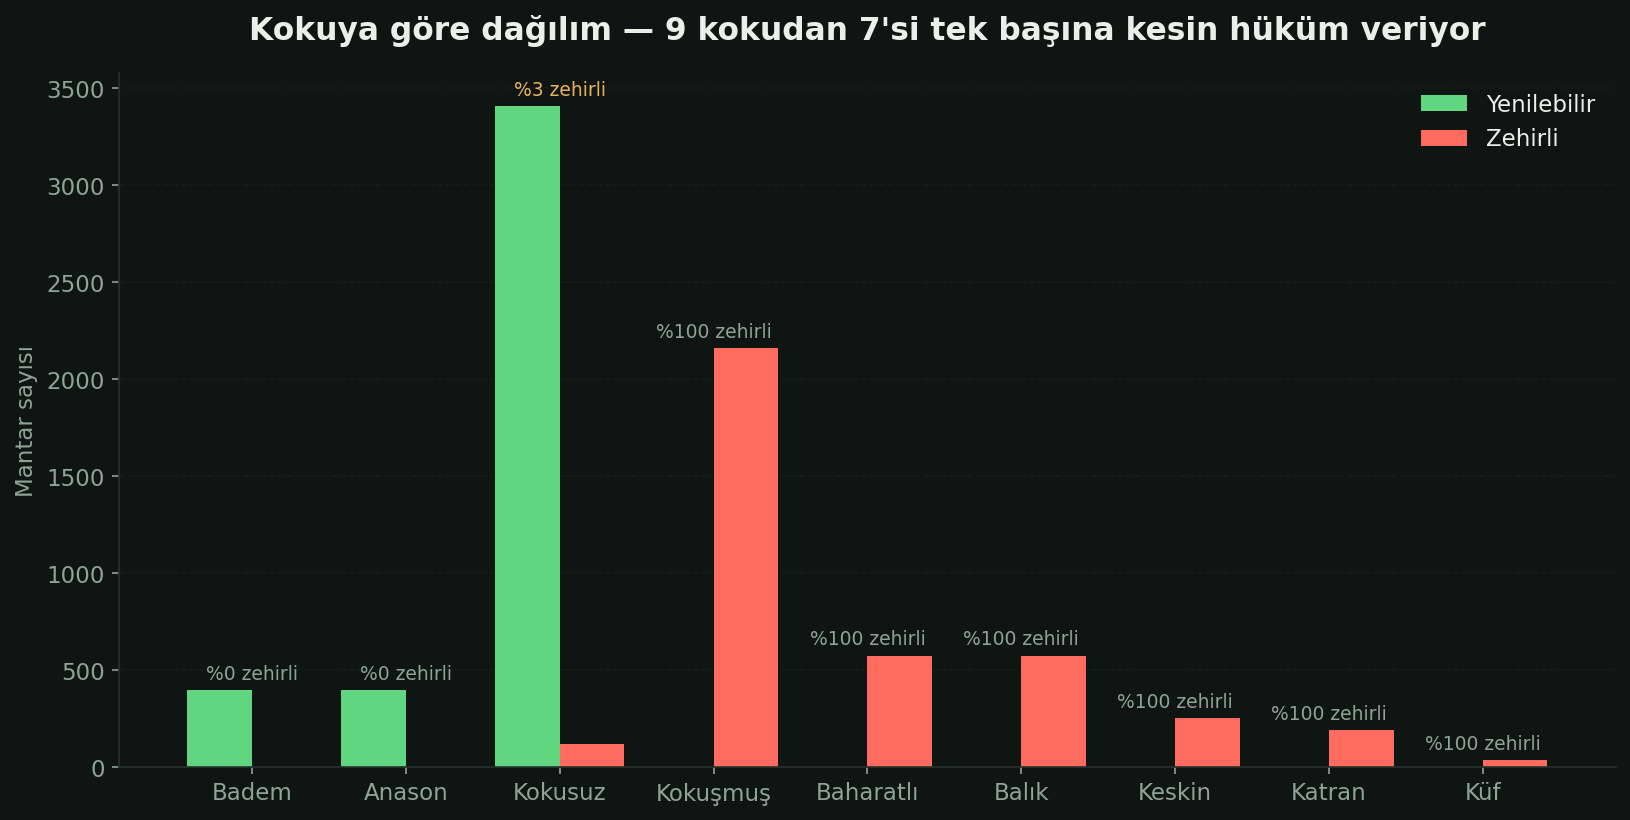

In [5]:
odor = insights["breakdown"]["odor"]["values"]
odor = sorted(odor, key=lambda v: v["poison_rate"])
names = [v["label"] for v in odor]
edible = [v["edible"] for v in odor]
poison = [v["poisonous"] for v in odor]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(11, 5.6))
ax.bar(x - 0.21, edible, 0.42, label="Yenilebilir", color=GREEN)
ax.bar(x + 0.21, poison, 0.42, label="Zehirli", color=RED)

for i, v in enumerate(odor):
    top = max(v["edible"], v["poisonous"])
    ax.text(i, top + 55, f'%{v["poison_rate"]:.0f} zehirli', ha="center",
            fontsize=9, color=AMBER if 0 < v["poison_rate"] < 100 else MUTED)

ax.set_xticks(x, names)
ax.set_ylabel("Mantar sayısı")
ax.set_title("Kokuya göre dağılım — 9 kokudan 7'si tek başına kesin hüküm veriyor", pad=16)
ax.legend(frameon=False, labelcolor=TEXT)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
finish(fig, "odor-impact.png")

## 4. Diğer güçlü ipuçları — zehirlilik oranları

kaydedildi → static/assets/poison-rate-grid.png


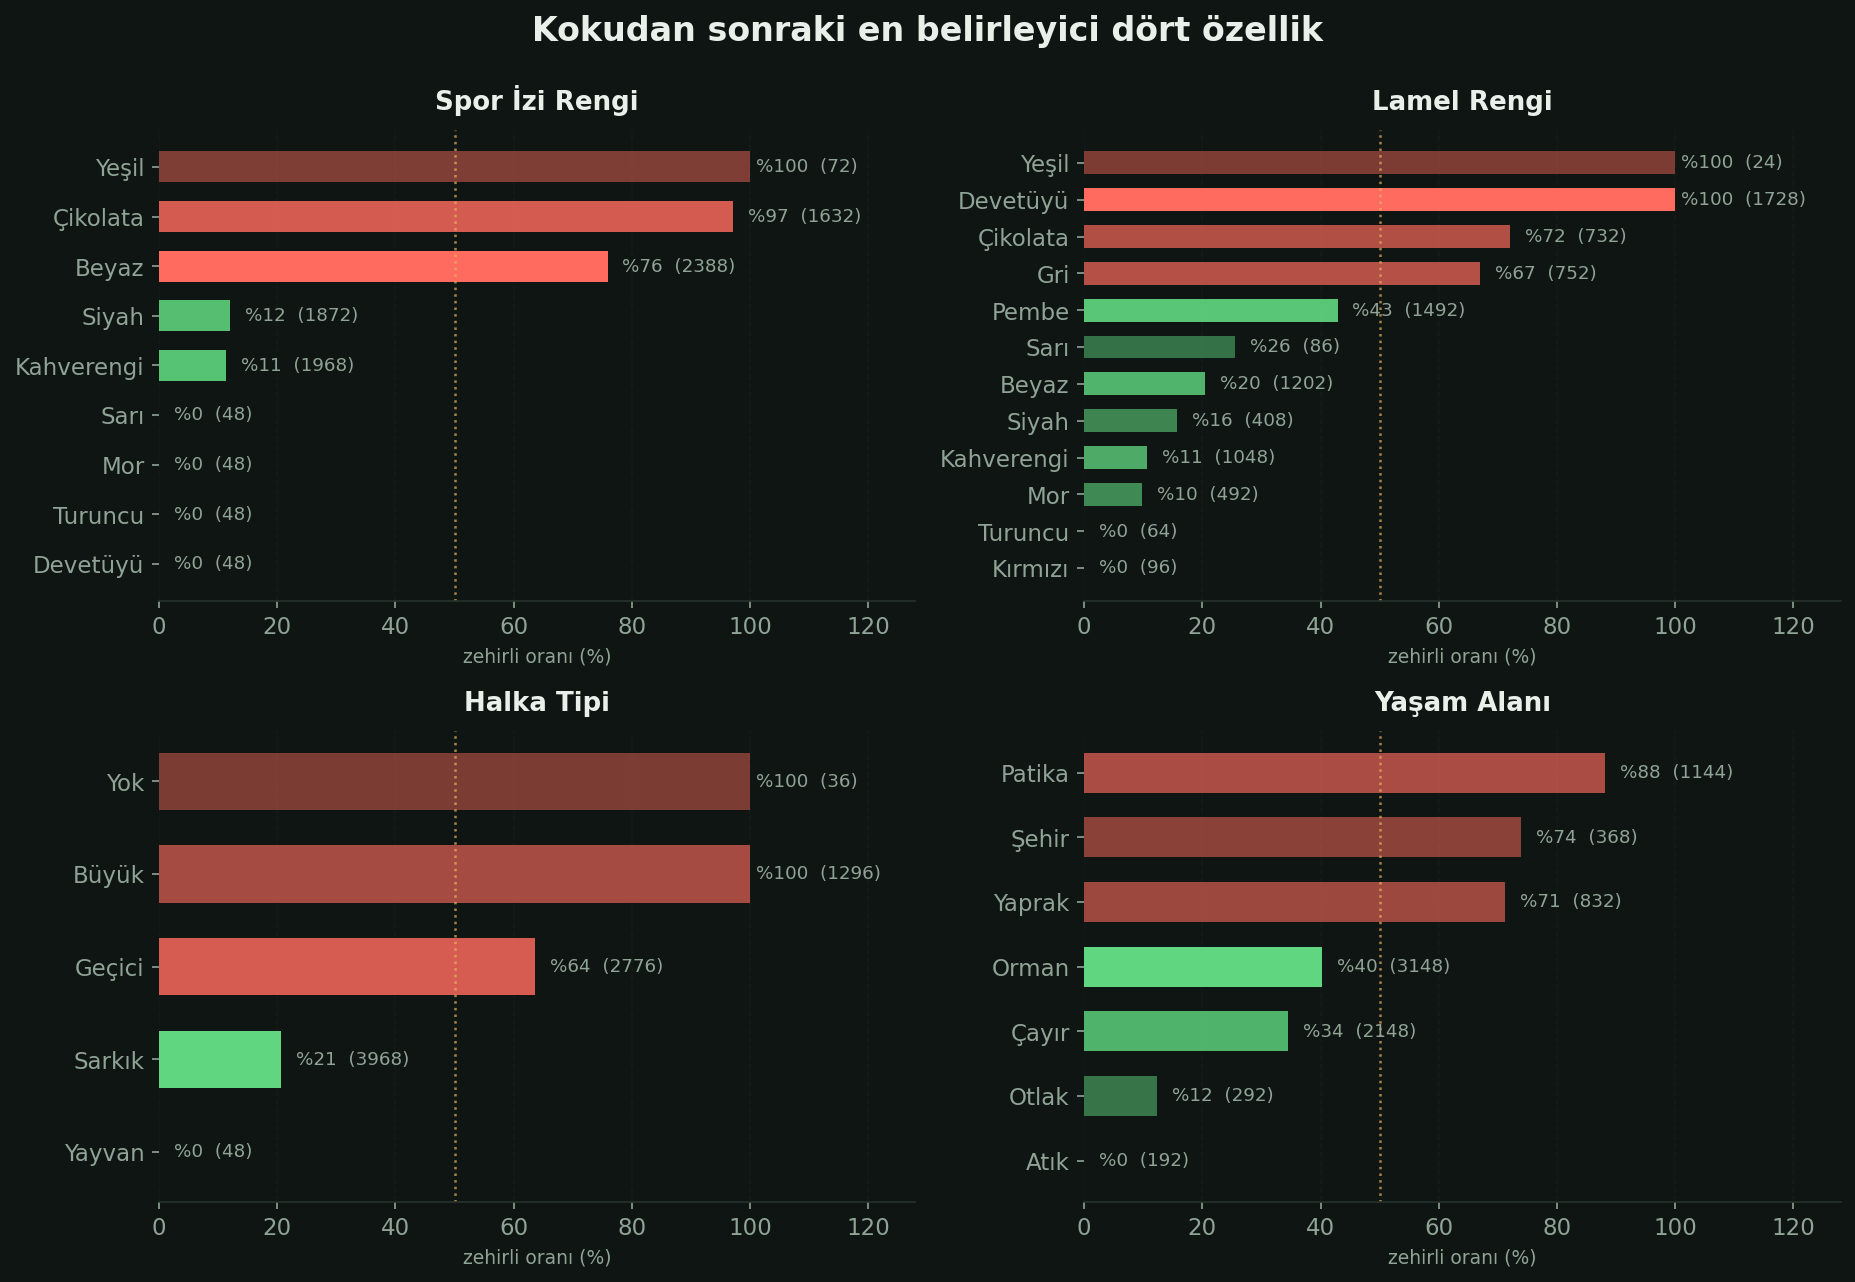

In [6]:
picks = ["spore-print-color", "gill-color", "ring-type", "habitat"]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6))
for ax, key in zip(axes.ravel(), picks):
    block = insights["breakdown"][key]
    vals = sorted([v for v in block["values"] if v["count"] >= 20],
                  key=lambda v: v["poison_rate"])
    names = [v["label"] for v in vals]
    rates = [v["poison_rate"] for v in vals]
    counts = [v["count"] for v in vals]

    colors = [RED if r >= 50 else GREEN for r in rates]
    alphas = [0.45 + 0.55 * (c / max(counts)) for c in counts]
    bars = ax.barh(names, rates, height=0.62, color=colors)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)
    for bar, r, c in zip(bars, rates, counts):
        ax.text(min(r + 2.5, 101), bar.get_y() + bar.get_height() / 2,
                f"%{r:.0f}  ({c})", va="center", fontsize=8.8, color=MUTED)

    ax.axvline(50, color=AMBER, linestyle=":", linewidth=1.2, alpha=0.7)
    ax.set_xlim(0, 128)
    ax.set_title(block["label"], fontsize=12.5, pad=10)
    ax.set_xlabel("zehirli oranı (%)", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.2)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)

fig.suptitle("Kokudan sonraki en belirleyici dört özellik", fontsize=16,
             fontweight="bold", y=0.99)
finish(fig, "poison-rate-grid.png")

## 5. Modelin eğitim süreci

kaydedildi → static/assets/training-curves.png


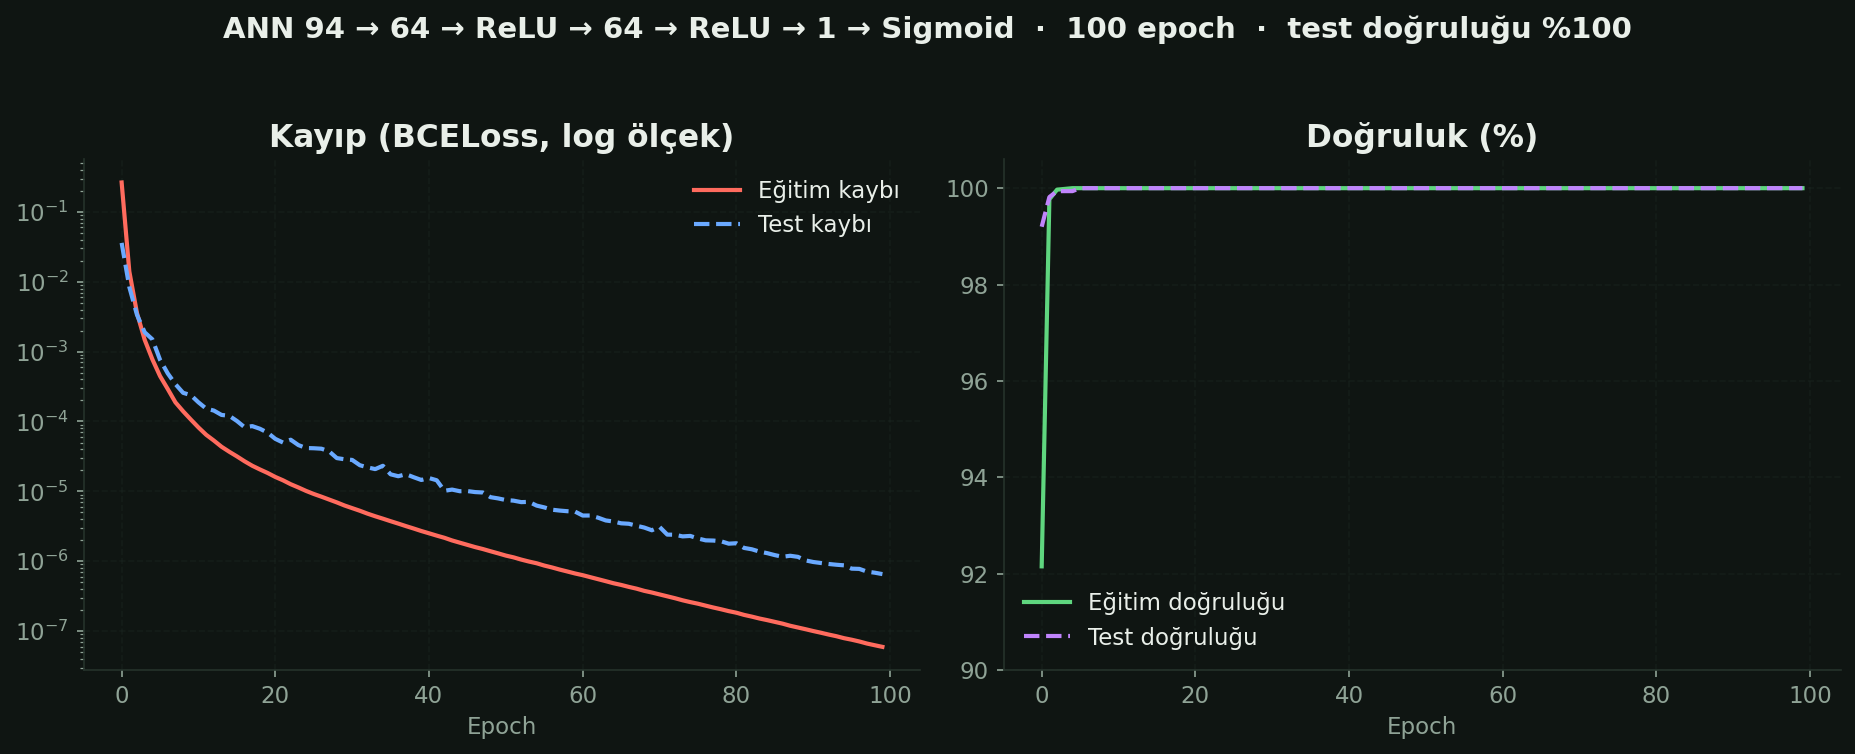

In [7]:
c = insights["curves"]
epochs = np.arange(len(c["train_loss"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax1.plot(epochs, c["train_loss"], color=RED, lw=2, label="Eğitim kaybı")
ax1.plot(epochs, c["test_loss"], color="#6aa9ff", lw=2, ls="--", label="Test kaybı")
ax1.set_yscale("log")
ax1.set_title("Kayıp (BCELoss, log ölçek)")
ax1.set_xlabel("Epoch")

ax2.plot(epochs, c["train_acc"], color=GREEN, lw=2, label="Eğitim doğruluğu")
ax2.plot(epochs, c["test_acc"], color="#c084fc", lw=2, ls="--", label="Test doğruluğu")
ax2.set_ylim(90, 100.6)
ax2.set_title("Doğruluk (%)")
ax2.set_xlabel("Epoch")

for ax in (ax1, ax2):
    ax.grid(linestyle="--", alpha=0.25)
    ax.legend(frameon=False, labelcolor=TEXT)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

m = insights["model"]
fig.suptitle(f'ANN {m["architecture"]}  ·  {m["epochs"]} epoch  ·  '
             f'test doğruluğu %{m["test_accuracy"]:.0f}',
             fontsize=14, fontweight="bold", y=1.04)
finish(fig, "training-curves.png")

## 6. Test kümesi karmaşıklık matrisi

kaydedildi → static/assets/confusion-matrix.png


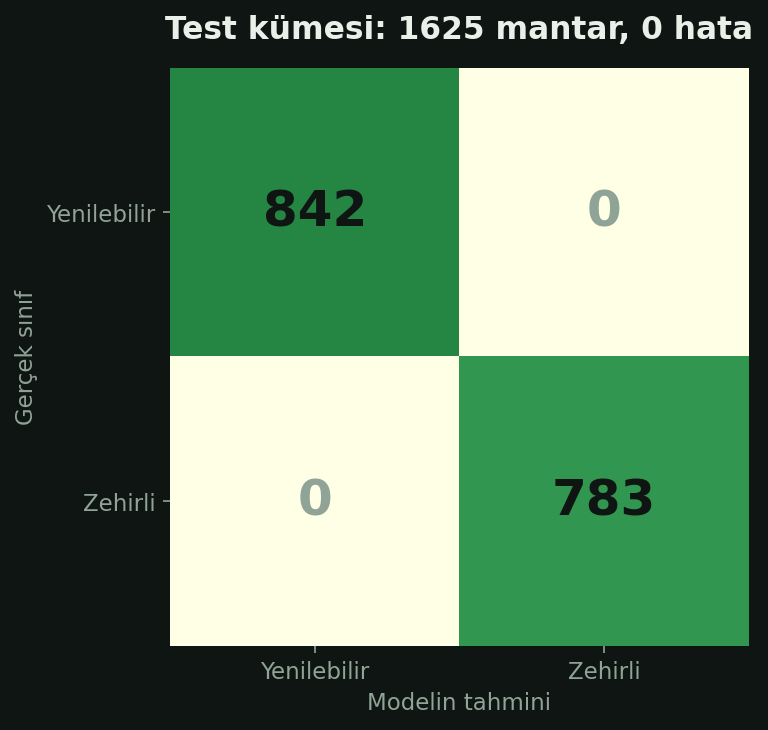

In [8]:
cm = np.array(insights["model"]["confusion_matrix"])
labels = ["Yenilebilir", "Zehirli"]

fig, ax = plt.subplots(figsize=(5.8, 5))
ax.imshow(cm, cmap="YlGn", vmin=0, vmax=cm.max() * 1.35)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                fontsize=24, fontweight="bold",
                color="#0f1512" if cm[i, j] > 0 else MUTED)

ax.set_xticks([0, 1], labels)
ax.set_yticks([0, 1], labels)
ax.set_xlabel("Modelin tahmini")
ax.set_ylabel("Gerçek sınıf")
ax.set_title(f'Test kümesi: {insights["model"]["test_size"]} mantar, 0 hata', pad=14)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
finish(fig, "confusion-matrix.png")

---
**Tüm grafikler `static/assets/` altına kaydedildi ve web sitesinin bilgi bankası bölümünde kullanılıyor.**